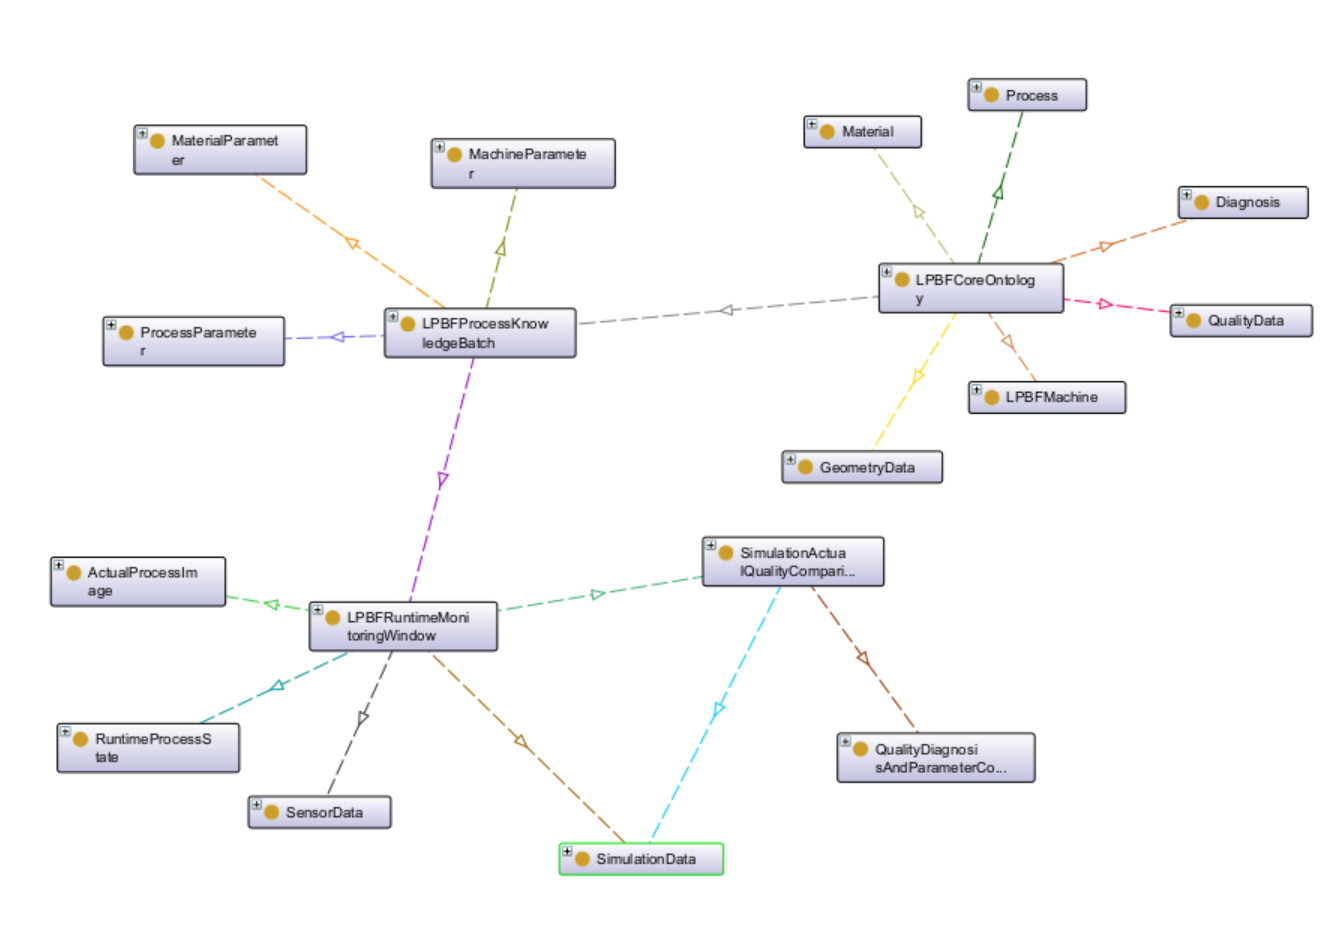

## 1. LPBFCoreOntology（LPBF 核心本體）

LPBFCoreOntology 是整個 LPBF 系統的基礎本體，用來定義 LPBF 製程中主要的知識類別與資料關係。

### 主要內容

- LPBF 機台
- 材料
- 製程
- 幾何資料
- 品質資料
- 診斷


---

## 2. LPBFProcessKnowledgeBatch（LPBF 製程知識批次）

LPBFProcessKnowledgeBatch 用來整理單次加工或單一批次加工所需要的製程知識與輸入資料。

### 主要內容

- 材料參數
- 機台參數
- 製程參數
- STL 工件模型
- LaserPath
- Layer 資料

### 說明

製程知識批次負責將 LPBF 加工前所需的資料進行整合，例如材料性質、機台設定、雷射功率、掃描速度、STL 模型、雷射路徑與切層資料。這些資料可作為後續模擬分析與實際加工監測的輸入基礎。

---

## 3. LPBFRuntimeMonitoringWindow（LPBF Runtime 監測視窗）

LPBFRuntimeMonitoringWindow 用來描述 LPBF 加工過程中的即時監測資料與狀態資訊。

### 主要內容

- 實際加工影像
- 模擬資料

### 說明

Runtime 監測視窗負責整合加工過程中的即時資料，例如熔池影像、模擬結果與。此階段可用來觀察加工是否穩定，並提供後續品質比較與異常診斷的依據。

---

## 4. SimulationActualQualityComparison（模擬資料與實際品質資料比較）

SimulationActualQualityComparison 用來比較模擬結果與實際量測結果之間的差異。

### 主要內容

- 模擬表面高度 vs 實際表面高度

### 說明

此階段主要將模擬產生的品質資料與實際量測資料進行對比，例如比較模擬表面高度與實際表面高度是否一致。透過差異分析，可以判斷模擬結果是否能反映實際加工品質。

---

## 5. QualityDiagnosisAndParameterCorrection（品質判斷、異常診斷、參數修正建議）

QualityDiagnosisAndParameterCorrection 是整個架構的診斷與決策階段，用來根據比較結果進行品質判斷與參數調整建議。

### 主要內容

- 品質判斷
- 異常診斷
- 參數修正建議

### 說明

此階段會根據模擬與實際品質比較結果，判斷加工品質是否合格，並進一步分析可能的異常原因，例如表面高度不均、熔融不足、過度堆積或邊界變形等問題。最後系統可提出製程參數修正建議，例如調整雷射功率、掃描速度、掃描路徑或補償策略。

---

# Overall Workflow（整體流程）

```text
LPBFCoreOntology
LPBF 核心本體
        ↓
LPBFProcessKnowledgeBatch
LPBF 製程知識批次
        ↓
LPBFRuntimeMonitoringWindow
LPBF Runtime 監測視窗
        ↓
SimulationActualQualityComparison
模擬資料與實際品質資料比較
        ↓
QualityDiagnosisAndParameterCorrection
品質判斷、異常診斷、參數修正建議

## output


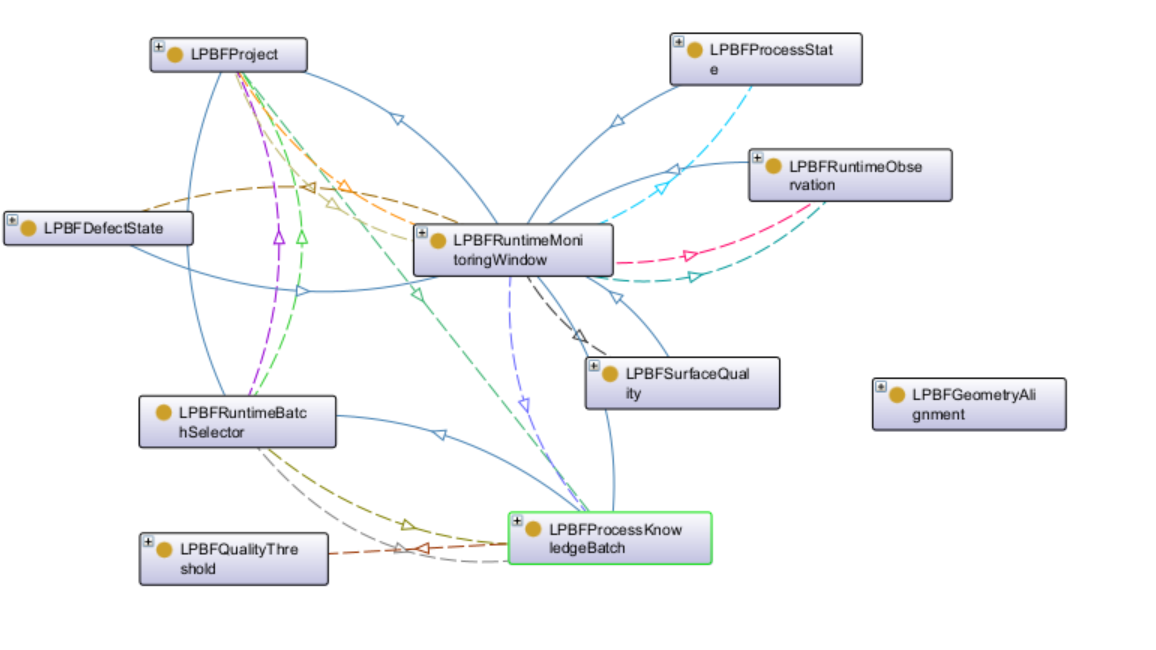

# LPBF Output TTL 關聯圖簡化說明

這張圖是 **LPBF Output TTL 的本體關聯圖**，用來描述 LPBF 製程輸出資料如何從專案、批次、Runtime 監測資料，推論到品質狀態與異常狀態。

---

## 1. 核心節點：LPBFRuntimeMonitoringWindow

**LPBFRuntimeMonitoringWindow** 是整張圖的核心，代表 LPBF 加工過程中的 **Runtime 監測視窗**。

它負責整合加工中的即時資料，例如：

- 雷射功率
- 掃描速度
- 熔池影像
- 熱場資料
- 冷卻時間
- 表面高度

---

## 2. 專案與批次資料

**LPBFProject** 代表整個 LPBF 專案資料。

**LPBFProcessKnowledgeBatch** 代表 LPBF 加工批次，例如：

- Batch A
- Batch B
- Batch C

**LPBFRuntimeBatchSelector** 用來選擇目前 Runtime 系統正在分析哪一個專案與哪一個批次。

---

## 3. 製程品質門檻

**LPBFQualityThreshold** 代表製程品質判斷門檻。

例如：

- 表面高度差 0–20 µm：Good
- 表面高度差 20–50 µm：Warning
- 表面高度差大於 50 µm：Poor

這些門檻會用來判斷加工品質是否正常。

---

## 4. Runtime 感測資料

**LPBFRuntimeObservation** 代表 Runtime 監測視窗收集到的感測與模擬資料。

包含：

- 雷射功率
- 掃描速度
- 熔池影像
- 熱覆蓋資料
- 冷卻時間
- 模擬表面高度
- 實際表面高度
- 表面高度差

---

## 5. 推論結果

Runtime 監測資料會根據品質門檻推論出兩種結果：

### LPBFSurfaceQuality：表面品質

- SurfaceHeight_Good：表面高度良好
- SurfaceHeight_Warning：表面高度警告
- SurfaceHeight_Poor：表面高度不良

### LPBFDefectState：LPBF 異常狀態

- LackOfFusionRisk：熔融不足風險
- OverMeltingRisk：過度熔融風險
- BallingRisk：球化風險

---

## 6. 幾何對齊資料

**LPBFGeometryAlignment** 代表 Layer、LaserPath 與 STL 的對齊資料。

它的作用是把 Runtime 監測資料對應到實際加工位置，例如：

- 對應哪一個 STL 工件模型
- 對應哪一層 Layer
- 對應哪一段 LaserPath

---

## 7. 整體流程

```text
LPBFProject專案資料
    ↓
LPBFProcessKnowledgeBatch製程批次
    ↓
LPBFQualityThreshold品質判斷
    ↓
LPBFRuntimeBatchSelector即時批次選擇
    ↓
LPBFRuntimeMonitoringWindow即時監測視窗
    ↓
LPBFRuntimeObservation即時觀測資料
    ↓
LPBFProcessState製程狀態
LPBFSurfaceQuality表面品質
LPBFDefectState缺陷狀態

## 兩者關聯

| 主關聯圖 | Output 關聯圖 | 白話說明 |
|---|---|---|
| LPBFCoreOntology<br>LPBF 核心本體 | LPBFProject<br>LPBF 專案資料 | 主關聯圖先定義整個 LPBF 系統有哪些資料，例如機台、材料、製程、幾何、品質與診斷。到了 Output 圖，這些定義會變成一個實際的 LPBF 專案資料。 |
| MaterialParameter / MachineParameter / ProcessParameter<br>材料參數 / 機台參數 / 製程參數 | LPBFProcessKnowledgeBatch<br>LPBF 製程知識批次 | 主關聯圖中的材料、機台、製程參數，會被整理成一個加工批次的知識資料，例如 Batch A、Batch B、Batch C。 |
| LPBFProcessKnowledgeBatch<br>LPBF 製程知識批次 | LPBFProcessKnowledgeBatch<br>LPBF 製程知識批次 | 這個資料在兩張圖都有，代表加工批次是整個系統很重要的資料來源。 |
| LPBFRuntimeMonitoringWindow<br>LPBF Runtime 監測視窗 | LPBFRuntimeMonitoringWindow<br>LPBF Runtime 監測視窗 | Runtime 監測視窗是兩張圖共同的核心，用來接收加工過程中的即時資料。 |
| ActualProcessImage / SensorData / SimulationData<br>實際加工影像 / 感測資料 / 模擬資料 | LPBFRuntimeObservation<br>LPBF Runtime 觀測資料 | 主關聯圖中的實際影像、感測資料與模擬資料，到了 Output 圖會被整理成 Runtime 觀測資料。也就是把加工中的資料集中記錄起來。 |
| RuntimeProcessState<br>即時加工狀態 | LPBFProcessState<br>LPBF 加工狀態 | 主關聯圖中的即時加工狀態，到了 Output 圖會變成最後輸出的加工狀態，例如穩定、警告或異常。 |
| QualityData<br>品質資料 | LPBFSurfaceQuality<br>LPBF 表面品質 | 主關聯圖中的品質資料，到了 Output 圖會轉成表面品質判斷，例如表面高度良好、警告或不良。 |
| Diagnosis<br>診斷 | LPBFDefectState<br>LPBF 異常狀態 | 主關聯圖中的診斷結果，到了 Output 圖會變成具體的異常狀態，例如熔融不足、過度熔融或球化風險。 |
| SimulationActualQualityComparison<br>模擬與實際品質比較 | LPBFSurfaceQuality / LPBFDefectState<br>LPBF 表面品質  | 模擬資料和實際品質資料比較後，可以判斷表面品質好不好，也可以判斷是否有異常風險。 |
| QualityDiagnosisAndParameterCorrection<br>品質診斷與參數修正建議 | LPBFProcessState / LPBFSurfaceQuality / LPBFDefectState<br>LPBF 加工狀態 / LPBF 表面品質 / LPBF 異常狀態 | 最後診斷結果會輸出三種重點：加工狀態、表面品質、異常風險。這些就是 Output TTL 最後要保存與顯示的結果。 |